# Task 2: Credit Risk Prediction
## Objective
Predict whether a loan applicant is likely to default on a loan.

 Data loaded! Shape: (614, 13)
 Missing values fixed!


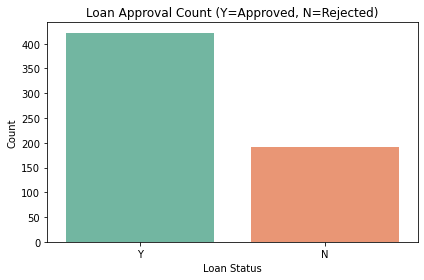

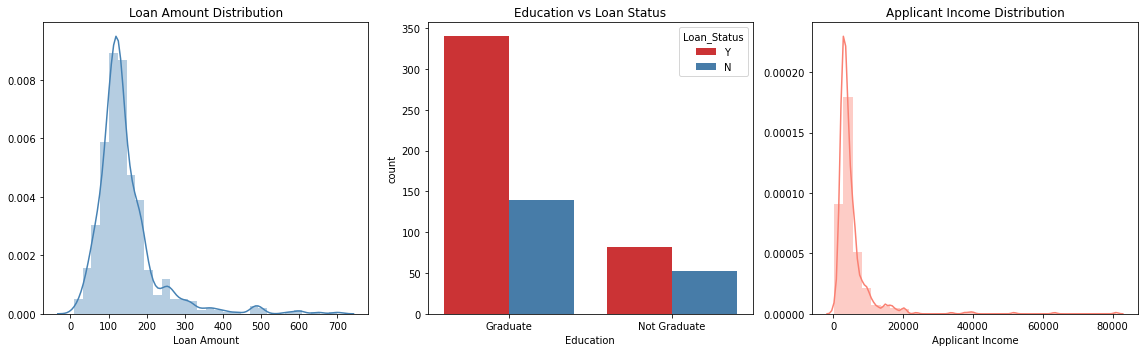

 Encoding done!
Features shape: (614, 11)
Target shape: (614,)

 Train samples: 491
 Test samples: 123

 Logistic Regression Accuracy: 78.86%
 Decision Tree Accuracy: 69.11%


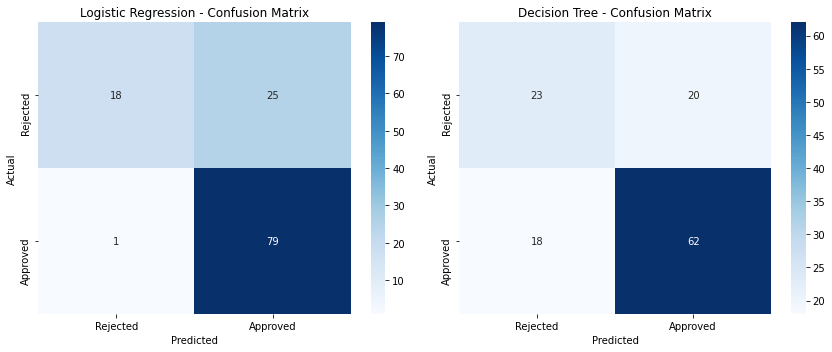


=== Logistic Regression Report ===
              precision    recall  f1-score   support

    Rejected       0.95      0.42      0.58        43
    Approved       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

=== Decision Tree Report ===
              precision    recall  f1-score   support

    Rejected       0.56      0.53      0.55        43
    Approved       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123


 Task 2 Complete!


In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATA 
df = pd.read_csv('/kaggle/input/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv')
print(" Data loaded! Shape:", df.shape)

# 2. FIX MISSING VALUES
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].median(), inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
print(" Missing values fixed!")

# 3. VISUALIZATIONS

# Plot 1: Loan Status Count
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', palette='Set2')
plt.title('Loan Approval Count (Y=Approved, N=Rejected)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Plot 2: Key Features (using distplot instead of histplot)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.distplot(df['LoanAmount'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Loan Amount Distribution')
axes[0].set_xlabel('Loan Amount')

sns.countplot(data=df, x='Education', hue='Loan_Status', ax=axes[1], palette='Set1')
axes[1].set_title('Education vs Loan Status')
axes[1].set_xlabel('Education')

sns.distplot(df['ApplicantIncome'], bins=30, ax=axes[2], color='salmon')
axes[2].set_title('Applicant Income Distribution')
axes[2].set_xlabel('Applicant Income')

plt.tight_layout()
plt.show()

# 4. ENCODE TEXT COLUMNS
le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education',
                    'Self_Employed', 'Property_Area', 'Loan_Status']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print(" Encoding done!")

# 5. PREPARE FEATURES & TARGET
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# 6. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("\n Train samples:", X_train.shape[0])
print(" Test samples:", X_test.shape[0])

# 7. TRAIN LOGISTIC REGRESSION 
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
print(f"\n Logistic Regression Accuracy: {accuracy_score(y_test, lr_predictions)*100:.2f}%")

# 8. TRAIN DECISION TRE 
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
print(f" Decision Tree Accuracy: {accuracy_score(y_test, dt_predictions)*100:.2f}%")

# 9. CONFUSION MATRIX
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(axes,
                             [lr_predictions, dt_predictions],
                             ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    ax.set_title(f'{title} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# ── 10. CLASSIFICATION REPORT ─────────────────────
print("\n=== Logistic Regression Report ===")
print(classification_report(y_test, lr_predictions,
      target_names=['Rejected', 'Approved']))

print("=== Decision Tree Report ===")
print(classification_report(y_test, dt_predictions,
      target_names=['Rejected', 'Approved']))

print("\n Task 2 Complete!")

## Conclusion

### Project Summary
In this task, we built a Credit Risk Prediction model to determine whether a loan 
applicant is likely to get their loan approved or rejected. We used the Loan Prediction 
Dataset which contained 614 applicants with 13 features including gender, education, 
income, loan amount, and credit history.

### Data Cleaning
The dataset had several missing values across multiple columns:
- Credit History had the most missing values (50)
- Self Employed had 32 missing values
- Gender had 13 missing values
- We filled numerical columns (LoanAmount, Loan_Amount_Term, Credit_History) 
  with their median values to avoid the effect of outliers.
- We filled categorical columns (Gender, Married, Dependents, Self_Employed) 
  with their most frequent values (mode).

### Key Observations from Visualizations
- The dataset is imbalanced — more applicants were approved than rejected.
- Graduates had a higher loan approval rate compared to non-graduates.
- Most loan amounts were concentrated between 100 and 200 (in thousands).
- Applicant income was heavily skewed, with most applicants earning below 10,000 
  and a few high earners pulling the average up.

### Model Performance
We trained and compared two classification models:

1. Logistic Regression:
   - Accuracy: 78.86%
   - Very strong at detecting approved loans (99% recall)
   - Struggled slightly with rejected loans (only 42% recall)
   - Better overall performance and more reliable for this dataset

2. Decision Tree:
   - Accuracy: 69.11%
   - More balanced between approved and rejected predictions
   - Lower overall accuracy compared to Logistic Regression
   - More prone to overfitting on training data

### Key Insights
- Credit History was the strongest predictor of loan approval. Applicants 
  with a good credit history (value = 1) were significantly more likely 
  to get approved.
- Logistic Regression is the better model for this problem as it achieved 
  higher accuracy and is easier to interpret.
- The model is conservative — it prefers to approve loans rather than 
  reject them, which could be risky in a real banking scenario.

### What Could Be Improved
- Collecting more data on rejected applicants to balance the dataset.
- Using more advanced models like Random Forest or XGBoost for better accuracy.
- Applying techniques like SMOTE to handle the class imbalance between 
  approved and rejected applicants.
- Adding more features like credit score, existing debts, and employment 
  history for better predictions.

### Final Verdict
Logistic Regression is the recommended model for this credit risk prediction 
task, achieving 78.86% accuracy. Credit history is the most critical factor 
in determining loan approval, and banks should prioritize this feature when 
evaluating loan applications.